## Importaciones de librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime as dt

import sys
import os

# Agregamos la carpeta superior (la raíz del proyecto) al sistema de búsqueda
sys.path.append(os.path.abspath(".."))

from src.utils.cleaning_methods import charge_path, first_visualizer, normalize_string_columns, normalize_date_columns, identify_outliers, show_head, show_info, delete_columns, load_clean_data

## Carga de datos

In [2]:
# Declaración del Path y carga del csv en un dataframe
PATH = '../output/client_activity_rental.csv'
df = charge_path(PATH)
show_head(df)

,customer_id,first_name,last_name,email,active,address,district,postal_code,phone,country,city
0,218,vera,mccoy,vera.mccoy@sakilacustomer.org,1,1168 najafabad parkway,kabol,40301,886649065861,afghanistan,kabul
1,441,mario,cheatham,mario.cheatham@sakilacustomer.org,1,1924 shimonoseki drive,batna,52625,406784385440,algeria,batna
2,69,judy,gray,judy.gray@sakilacustomer.org,1,1031 daugavpils parkway,béchar,59025,107137400143,algeria,béchar
3,176,june,carroll,june.carroll@sakilacustomer.org,1,757 rustenburg avenue,skikda,89668,506134035434,algeria,skikda
4,320,anthony,schwab,anthony.schwab@sakilacustomer.org,1,1892 nabereznyje tšelny lane,tutuila,28396,478229987054,american samoa,tafuna
5,528,claude,herzog,claude.herzog@sakilacustomer.org,1,486 ondo parkway,benguela,35202,105882218332,angola,benguela
6,383,martin,bales,martin.bales@sakilacustomer.org,1,368 huánuco boulevard,namibe,17165,106439158941,angola,namibe
7,381,bobby,boudreau,bobby.boudreau@sakilacustomer.org,1,1368 maracaíbo boulevard,NaN,32716,934352415130,anguilla,south hill
8,359,willie,markham,willie.markham@sakilacustomer.org,1,1623 kingstown drive,buenos aires,91299,296394569728,argentina,almirante brown
9,560,jordan,archuleta,jordan.archuleta@sakilacustomer.org,1,1229 varanasi (benares) manor,buenos aires,40195,817740355461,argentina,avellaneda


## Exploración rápida del dataset

In [3]:
num_columnas, num_filas, num_duplicados, null_values, df_porcentaje_nulos_columna, df_describe_numeric, df_describe_categorical = first_visualizer(df)

In [4]:
show_head(df)

,customer_id,first_name,last_name,email,active,address,district,postal_code,phone,country,city
0,218,vera,mccoy,vera.mccoy@sakilacustomer.org,1,1168 najafabad parkway,kabol,40301,886649065861,afghanistan,kabul
1,441,mario,cheatham,mario.cheatham@sakilacustomer.org,1,1924 shimonoseki drive,batna,52625,406784385440,algeria,batna
2,69,judy,gray,judy.gray@sakilacustomer.org,1,1031 daugavpils parkway,béchar,59025,107137400143,algeria,béchar
3,176,june,carroll,june.carroll@sakilacustomer.org,1,757 rustenburg avenue,skikda,89668,506134035434,algeria,skikda
4,320,anthony,schwab,anthony.schwab@sakilacustomer.org,1,1892 nabereznyje tšelny lane,tutuila,28396,478229987054,american samoa,tafuna
5,528,claude,herzog,claude.herzog@sakilacustomer.org,1,486 ondo parkway,benguela,35202,105882218332,angola,benguela
6,383,martin,bales,martin.bales@sakilacustomer.org,1,368 huánuco boulevard,namibe,17165,106439158941,angola,namibe
7,381,bobby,boudreau,bobby.boudreau@sakilacustomer.org,1,1368 maracaíbo boulevard,NaN,32716,934352415130,anguilla,south hill
8,359,willie,markham,willie.markham@sakilacustomer.org,1,1623 kingstown drive,buenos aires,91299,296394569728,argentina,almirante brown
9,560,jordan,archuleta,jordan.archuleta@sakilacustomer.org,1,1229 varanasi (benares) manor,buenos aires,40195,817740355461,argentina,avellaneda


In [5]:
# Visualización del tamaño del dataframe
print(f'El dataset tiene {num_filas} filas.')
print(f'El dataset tiene {num_columnas} columnas.')

El dataset tiene 599 filas.
El dataset tiene 11 columnas.


In [6]:
# Visualización de registro duplicados
print(f'El dataset tiene {num_duplicados} duplicados.')

El dataset tiene 0 duplicados.


In [7]:
# Suma de valores nulos por columna
print(f'El dataset tiene {null_values} valores nulos.\n')
print('Valores nulos por columna:')
df_porcentaje_nulos_columna

El dataset tiene 3 valores nulos.

Valores nulos por columna:


(customer_id    0.000000
 first_name     0.000000
 last_name      0.000000
 email          0.000000
 active         0.000000
 address        0.000000
 district       0.500835
 postal_code    0.000000
 phone          0.000000
 country        0.000000
 city           0.000000
 dtype: float64,
 2)

In [8]:
show_info(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  599 non-null    int64 
 1   first_name   599 non-null    object
 2   last_name    599 non-null    object
 3   email        599 non-null    object
 4   active       599 non-null    int64 
 5   address      599 non-null    object
 6   district     596 non-null    object
 7   postal_code  599 non-null    int64 
 8   phone        599 non-null    int64 
 9   country      599 non-null    object
 10  city         599 non-null    object
dtypes: int64(4), object(7)
memory usage: 51.6+ KB


In [9]:
df_describe_numeric

,customer_id,active,postal_code,phone
count,599.000000,599.000000,599.000000,5.990000e+02
mean,300.000000,0.974958,50222.313856,4.985950e+11
std,173.060683,0.156382,28986.085055,3.015405e+11
min,1.000000,0.000000,3.000000,8.925233e+08
25%,150.500000,1.000000,25182.500000,2.138130e+11
50%,300.000000,1.000000,50805.000000,4.930085e+11
75%,449.500000,1.000000,74920.000000,7.634198e+11
max,599.000000,1.000000,99865.000000,9.980098e+11


In [10]:
df_describe_categorical

,first_name,last_name,email,address,district,country,city
count,599,599,599,599,596,599,599
unique,591,599,599,599,375,108,597
top,leslie,mccoy,vera.mccoy@sakilacustomer.org,1168 najafabad parkway,buenos aires,india,london
freq,2,1,1,1,10,60,2


Al realizar esta exploración podemos ver que el dataset no presenta duplicados, valores nulos y los diferentes tipos de columnas y sus tipos.
También podemos presenciar que las variables que poseen información de fecha están en formato texto y que la variable `release_year` es el mismo en todos los registros, por lo que no aporta información y tendríamos que proceder a elimnarla en futuros pasos.

## Normalización

In [11]:
# Copia del dataset para limpieza y análisis
df_clean = df.copy()

In [12]:
# Normalización a tipo fecha y string
df_clean = normalize_date_columns(df_clean)
df_clean = normalize_string_columns(df_clean)


In [13]:
show_info(df_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  599 non-null    int64 
 1   first_name   599 non-null    string
 2   last_name    599 non-null    string
 3   email        599 non-null    string
 4   active       599 non-null    int64 
 5   address      599 non-null    string
 6   district     596 non-null    string
 7   postal_code  599 non-null    int64 
 8   phone        599 non-null    int64 
 9   country      599 non-null    string
 10  city         599 non-null    string
dtypes: int64(4), string(7)
memory usage: 51.6 KB


## Creación de columnas adicionales y borrado de las columnas que no aporten valor

In [14]:
# Creación de la columna full_name uniendo el fist_name y el last_name
df_clean['full_name'] = df_clean['first_name'] + ' ' + df_clean['last_name']

## Eliminación de las columnas que ya no nos aporta información

In [15]:
# Eliminación de las columnas redundantes tras la creación de columnas adicionales a pertir de ellas
df_clean = delete_columns(df_clean, ['first_name', 'last_name'])

In [16]:
show_head(df_clean, 5)

,customer_id,email,active,address,district,postal_code,phone,country,city,full_name
0,218,veramccoy@sakilacustomerorg,1,1168 najafabad parkway,kabol,40301,886649065861,afghanistan,kabul,vera mccoy
1,441,mariocheatham@sakilacustomerorg,1,1924 shimonoseki drive,batna,52625,406784385440,algeria,batna,mario cheatham
2,69,judygray@sakilacustomerorg,1,1031 daugavpils parkway,bchar,59025,107137400143,algeria,bchar,judy gray
3,176,junecarroll@sakilacustomerorg,1,757 rustenburg avenue,skikda,89668,506134035434,algeria,skikda,june carroll
4,320,anthonyschwab@sakilacustomerorg,1,1892 nabereznyje telny lane,tutuila,28396,478229987054,american samoa,tafuna,anthony schwab


## Tratamiento de valores Nulos y Outliers

In [17]:
show_info(df_clean)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 599 entries, 0 to 598
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   customer_id  599 non-null    int64 
 1   email        599 non-null    string
 2   active       599 non-null    int64 
 3   address      599 non-null    string
 4   district     596 non-null    string
 5   postal_code  599 non-null    int64 
 6   phone        599 non-null    int64 
 7   country      599 non-null    string
 8   city         599 non-null    string
 9   full_name    599 non-null    string
dtypes: int64(4), string(6)
memory usage: 46.9 KB


In [18]:
# Filtrado de columnas numéricas y booleanas para análisis posteriores
variables_numericas = []
variables_categoricas = []

variables_a_ignorar = ['customer_id', 'postal_code', 'phone', 'email', 'address', 'district', 'city', 'country', 'full_name']

for col in df_clean.columns:
    if col in variables_a_ignorar:
        continue
    elif df_clean[col].dtype in ['int64', 'float64', 'int32']:
        variables_numericas.append(col)
    else:
        variables_categoricas.append(col)
print(f'Variables numéricas a analizar: {variables_numericas}')
print(f'Variables categóricas a analizar: {variables_categoricas}')

Variables numéricas a analizar: ['active']
Variables categóricas a analizar: []


### Tratamiento de valores Nulos

Intento de imputación de los valores nulos de la columna district agrpandolos por código postal, ciudad y país, usando la moda
Sustitución de nulos por "missing" en futuros análisis en el caso que se añadan mas registros.

In [19]:
df_clean['district'] = df_clean['district'].fillna(
    df_clean.groupby(['city', 'postal_code', 'country'])['district'].transform(
        lambda x: x.mode().iloc[0] if not x.mode().empty else 'missing'
    )
)

In [20]:
#Seleccionar los nombres de las columnas que son texto
columns_str = df_clean.select_dtypes("string").columns
print(columns_str)

for column in columns_str:
    df_clean[column] = df_clean[column].fillna("missing")

# Verificamos que ya no quedan nulos
print(df_clean.isnull().sum())

Index(['email', 'address', 'district', 'country', 'city', 'full_name'], dtype='object')
customer_id    0
email          0
active         0
address        0
district       0
postal_code    0
phone          0
country        0
city           0
full_name      0
dtype: int64


### Tratamiento de valores Outliers

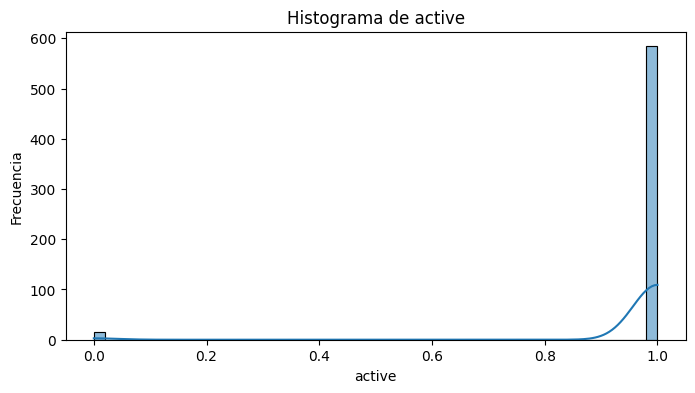

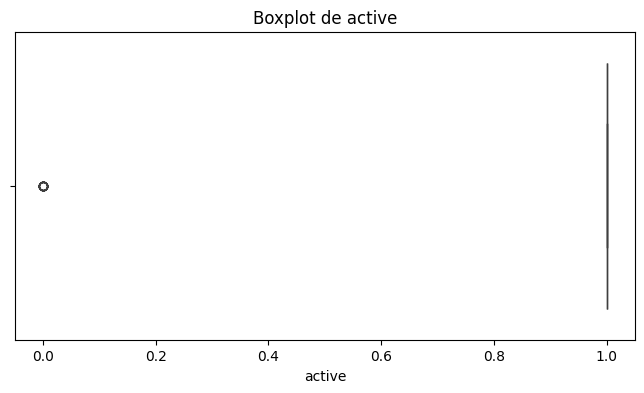

In [21]:
identify_outliers(df_clean, variables_numericas, variables_categoricas)

En este caso, solamente poseemos valores outliers en la columna amount, pero al tratarse de solamente 4 valores hemos decidido no realizar ningún tratamiento.

## Dashboard

### Alquileres por día y temporada

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='day_of_week_rental', hue='season')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5, 6], labels=['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo'])
plt.title('Cantidad de alquileres por día de la semana y temporada')
plt.show()
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, x='rental_month')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Mayo', 'Junio', 'Julio', 'Agosto'])
plt.xlabel('Mes de alquiler')
plt.ylabel('Cantidad de alquileres')
plt.title(f'Cantidad de alquiremes por mes')
plt.show()

ValueError: Could not interpret value `day_of_week_rental` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

### Histograma por año

In [ ]:
df_filtrado = df_clean[df_clean['rental_year'] != 2005]
conteo = len(df_filtrado)
print(conteo)

0


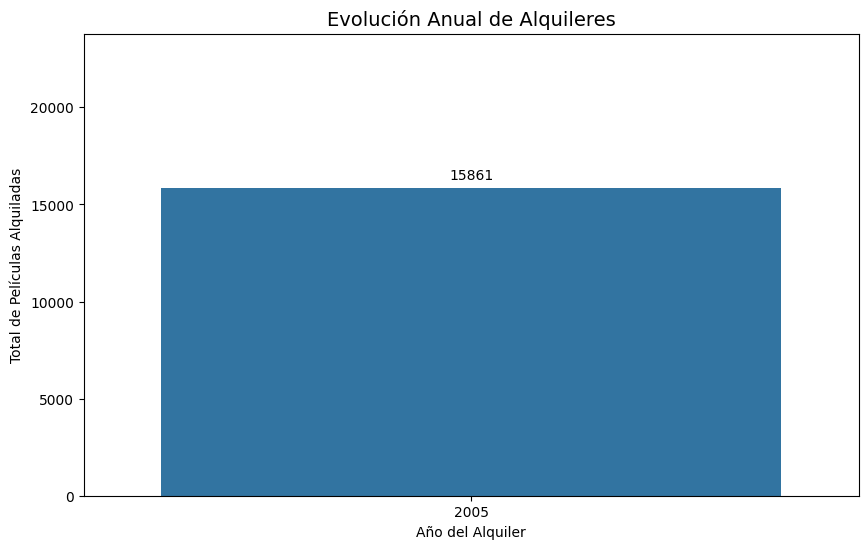

In [ ]:
plt.figure(figsize=(10, 6))

# Usamos el año de alquiler en el eje X
sns.countplot(data=df_clean, x='rental_year')

# Añadimos etiquetas 
plt.title('Evolución Anual de Alquileres', fontsize=14)
plt.xlabel('Año del Alquiler')
plt.ylabel('Total de Películas Alquiladas')

# Añadimos el número exacto encima de cada barra para mayor claridad
ax = plt.gca()

max_height = df_clean['rental_year'].value_counts().max()
ax.set_ylim(0, max_height * 1.5)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.show()


### Histograma por horas del día 

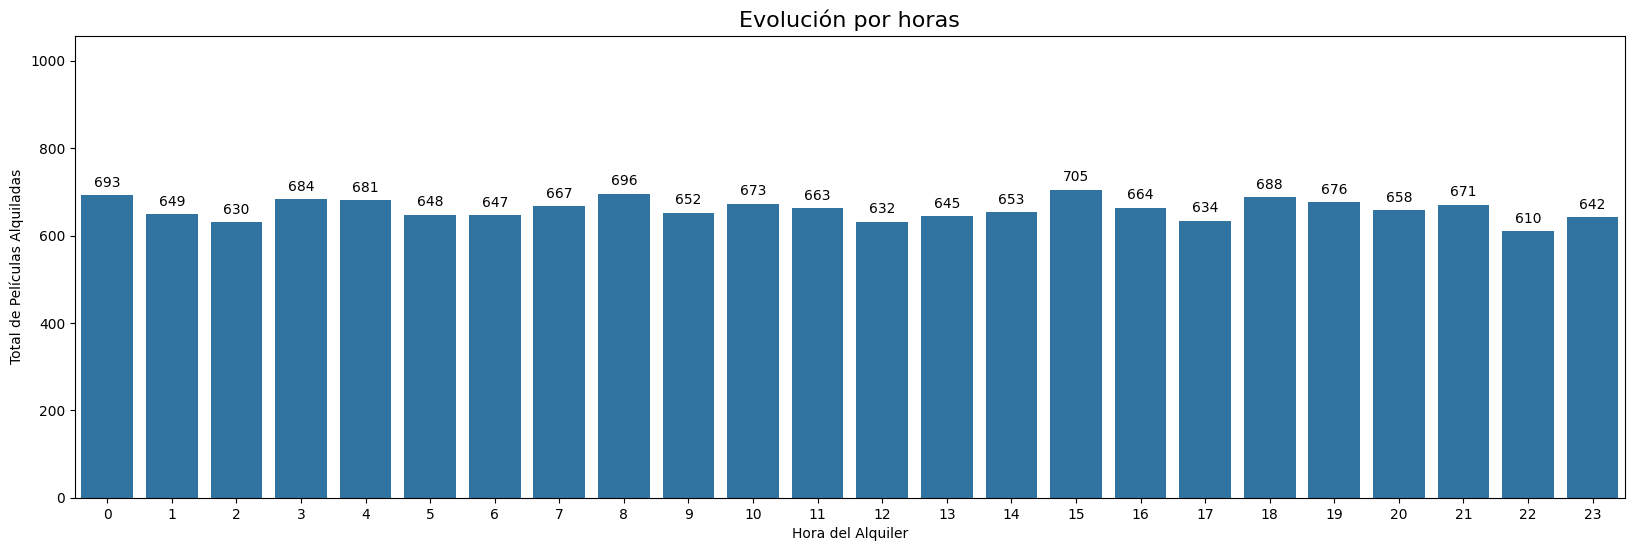

In [ ]:
plt.figure(figsize=(20, 6))

# Usamos la hora de alquiler en el eje X
sns.countplot(data=df_clean, x='rental_hour')

# Añadimos etiquetas 
plt.title('Evolución por horas', fontsize=16)
plt.xlabel('Hora del Alquiler')
plt.ylabel('Total de Películas Alquiladas')

# Modificar la altura de y para que quede mas estético
ax = plt.gca()
max_height = df_clean['rental_hour'].value_counts().max()
ax.set_ylim(0, max_height * 1.5)

# Añadimos el número exacto encima de cada barra para mayor claridad

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')
    
plt.show()

### Usuarios que mas alquilan

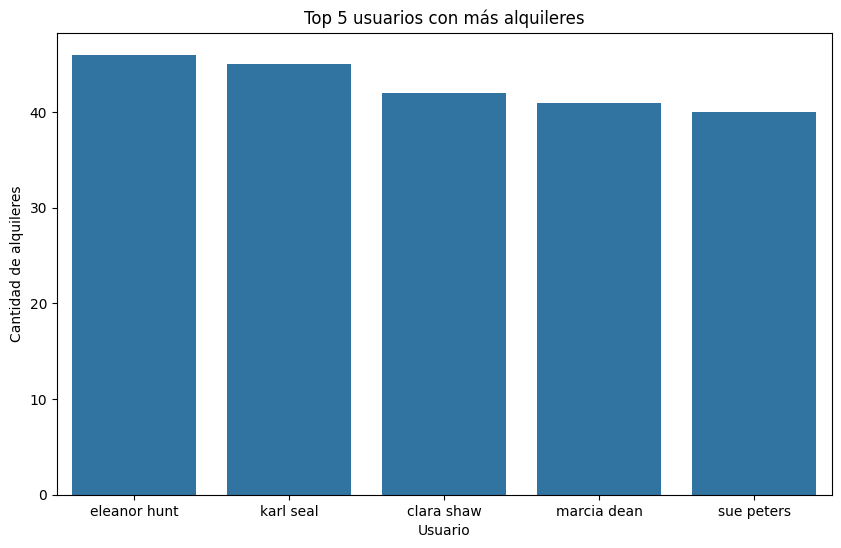

In [ ]:
df_top_5_user = df_clean['full_name'].value_counts().head(5)

plt.figure(figsize=(10, 6))
sns.barplot(x=df_top_5_user.index, y=df_top_5_user.values)
plt.xlabel('Usuario')
plt.ylabel('Cantidad de alquileres')
plt.title('Top 5 usuarios con más alquileres')
plt.show()